In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn import datasets

In [26]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [27]:
# Preparing and displaying the first five rows
housing_df = pd.DataFrame(data=housing.data, columns=housing.feature_names)
housing_df["HousePrice"] = housing.target
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [28]:
# Summary statistics
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [29]:
# Checking for null values accross all features
housing_df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

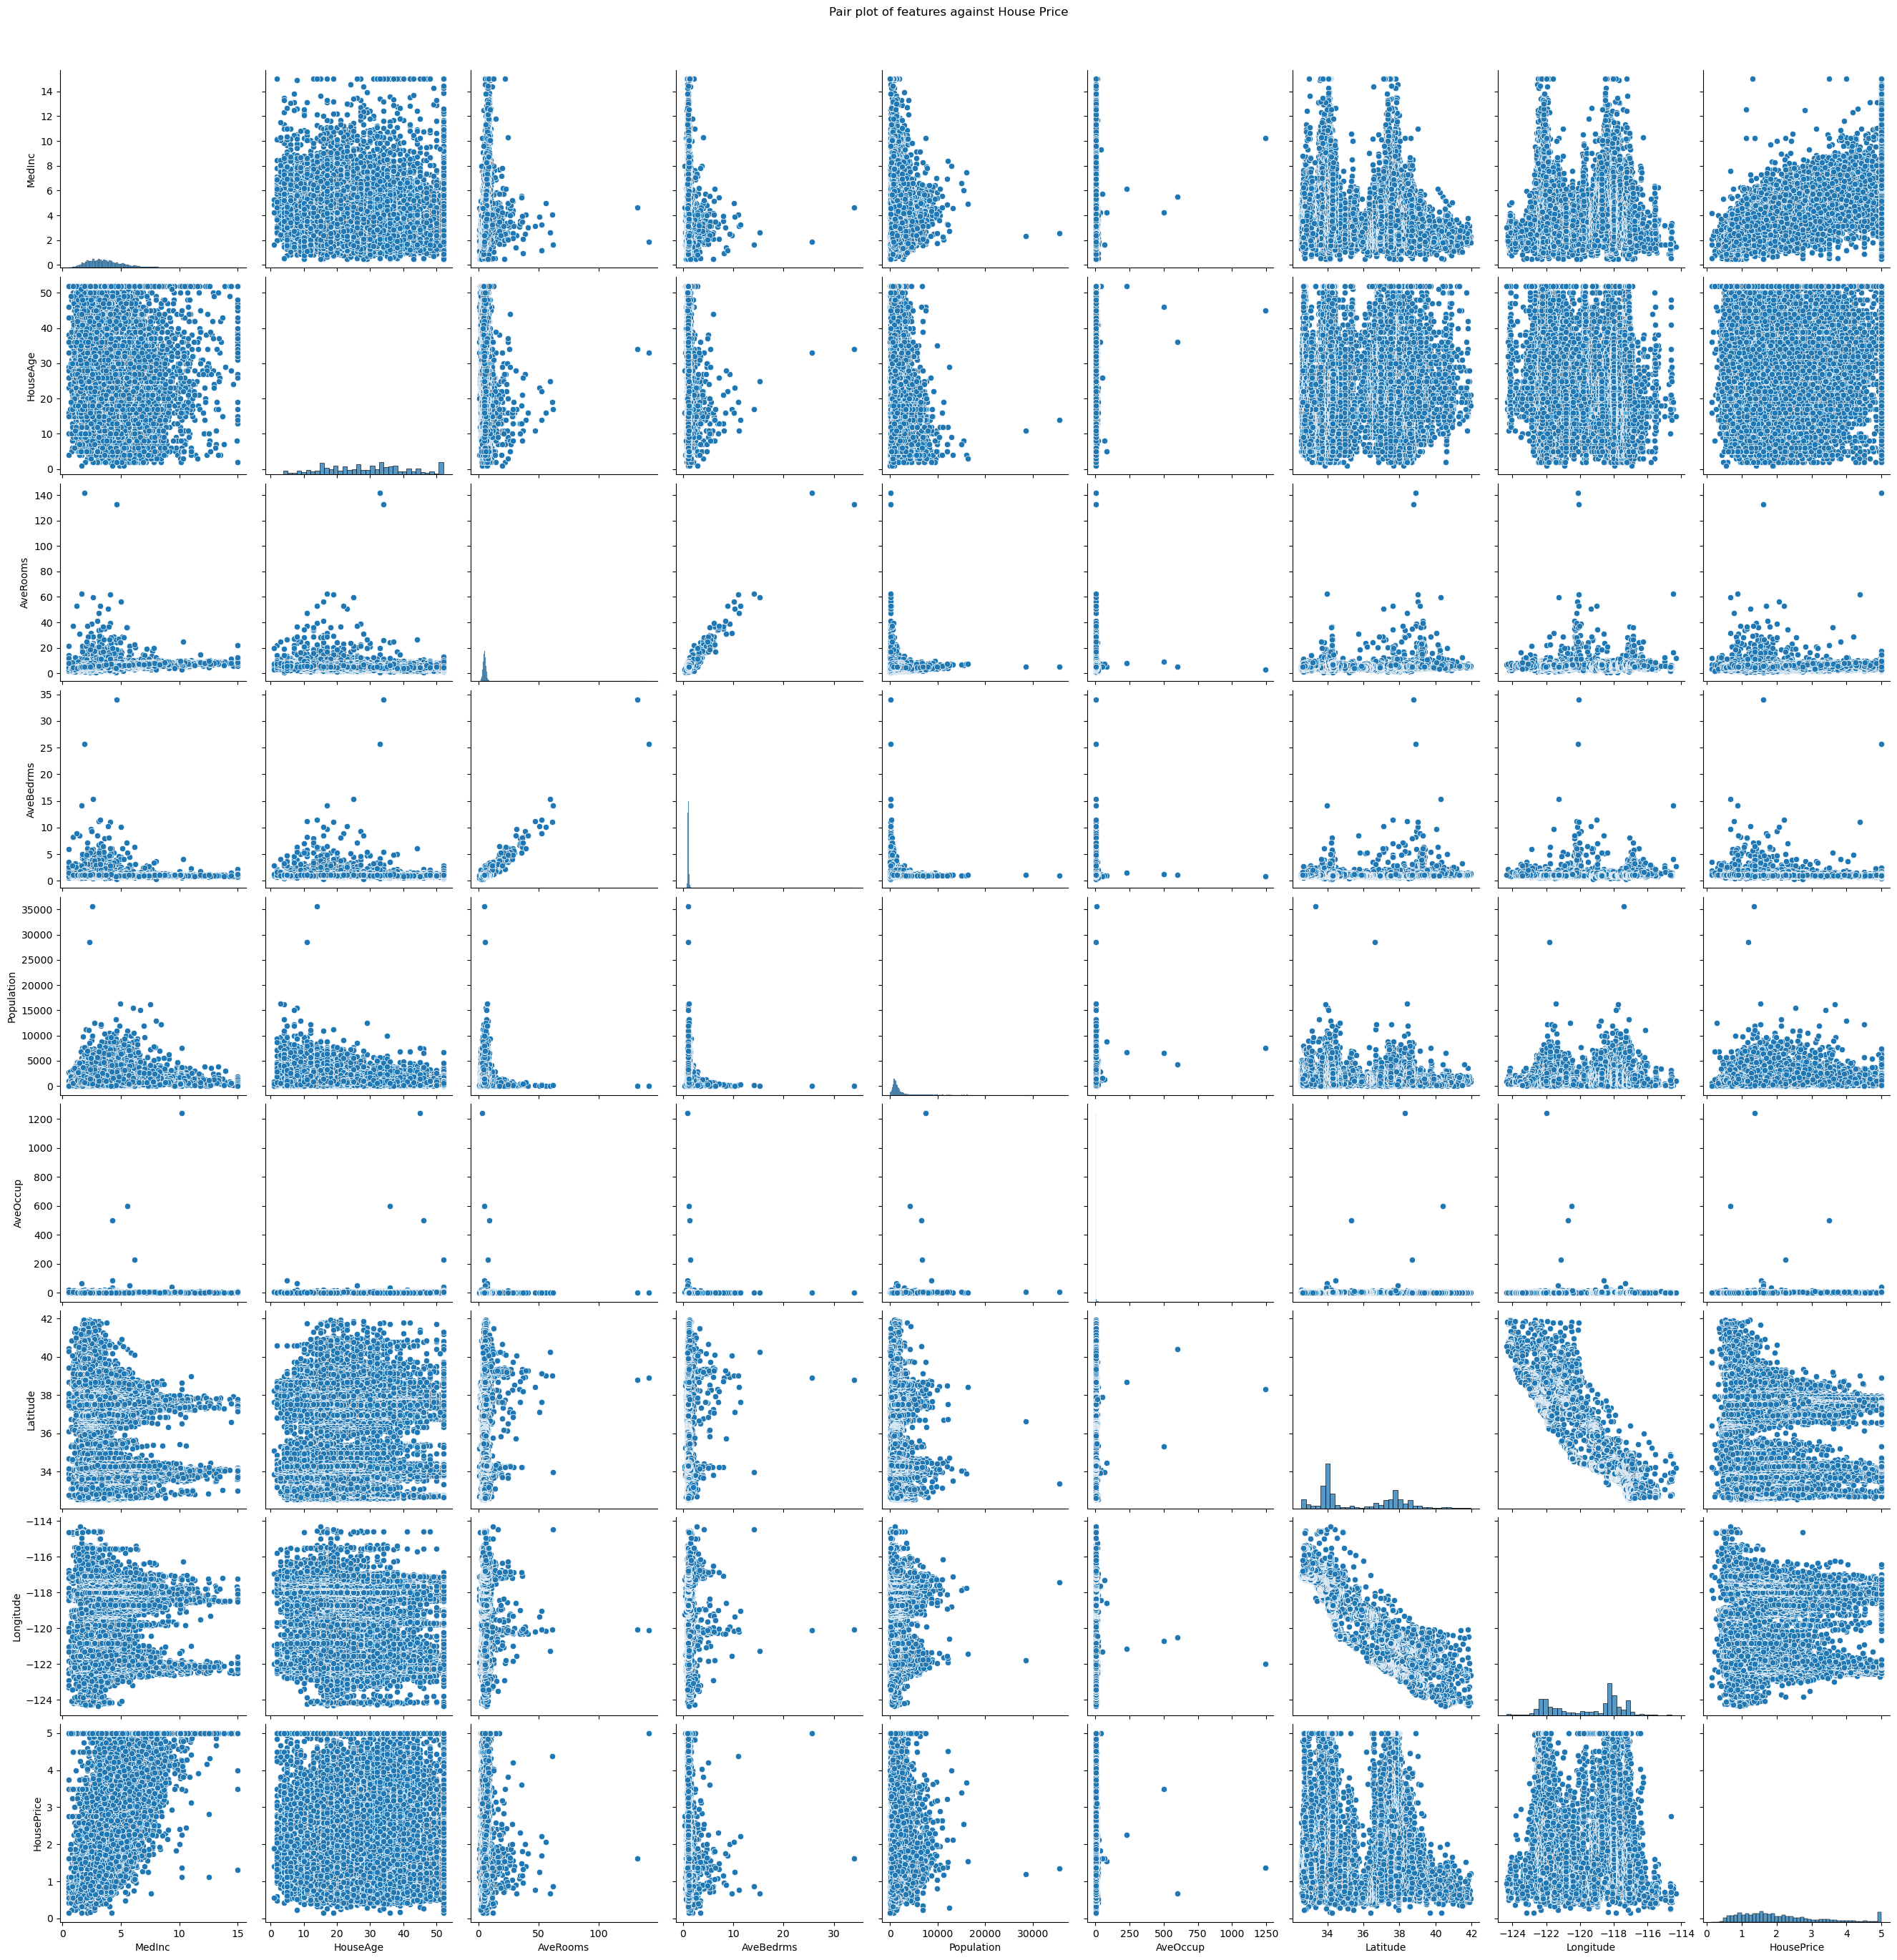

In [30]:
# Visualizing pairwise relationships in the housing_df feature against housePrice using a pairplot
sns.pairplot(housing_df, height=3)
plt.suptitle("Pair plot of features against House Price", y=1.02)
plt.show()

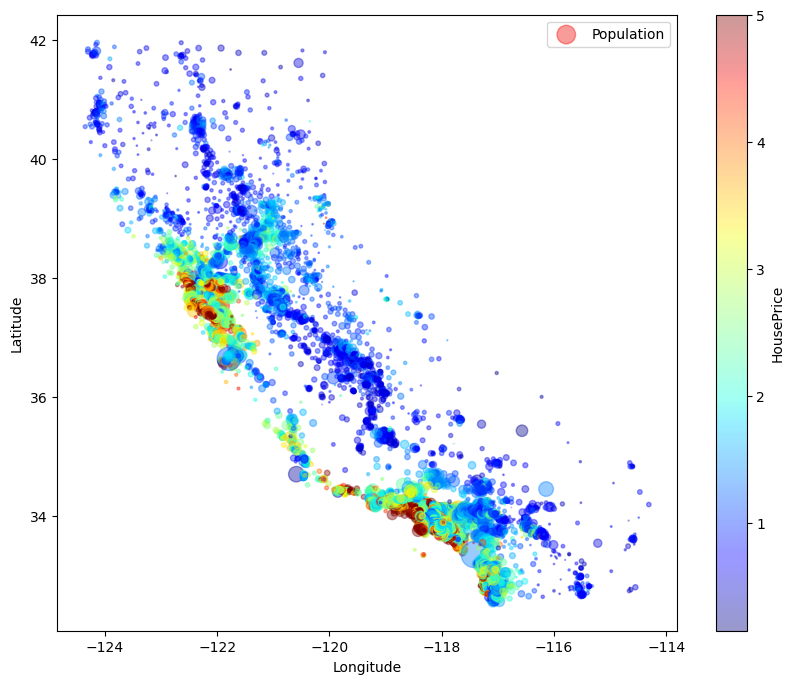

In [31]:
# Geographic Distribution of datapoints based on Longitude and Latitude, 
# Size of each point represents the population & and the color indicates the HousePrices,
# To see how house prices and population density vary accross different location
housing_df.plot(
    kind="scatter",
    x="Longitude",
    y="Latitude",
    alpha=0.4,
    s=housing_df["Population"]/100,
    label="Population",
    c="HousePrice",
    cmap="jet",
    colorbar=True,
    figsize=(10,8)
)
plt.show()

<Axes: >

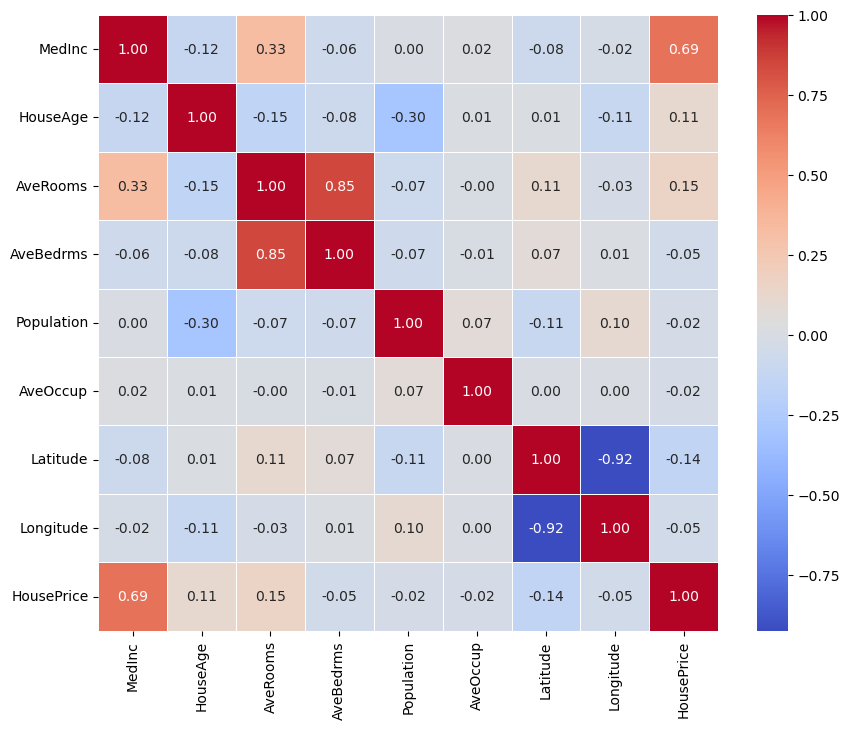

In [32]:
# Checking for multicollinearity using the variance inflation factor (VIF) for each predictor
# Compute the correlation variable using heatmap
corr = housing_df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

As you can see above, the heatmap displays correlation coefficients b/t housing related variables with values ranging from -1 blue to 1 red

In [33]:
# Compute and display the absolute correlation values of HousePrice sorting them in descending order
corr["HousePrice"].abs().sort_values(ascending=False)

HousePrice    1.000000
MedInc        0.688075
AveRooms      0.151948
Latitude      0.144160
HouseAge      0.105623
AveBedrms     0.046701
Longitude     0.045967
Population    0.024650
AveOccup      0.023737
Name: HousePrice, dtype: float64

The above absolute correlation facilitates the identification of the most influential indicators strongly associated with HousePrice e.g MedInc is a strong positive indicator for predicting house price

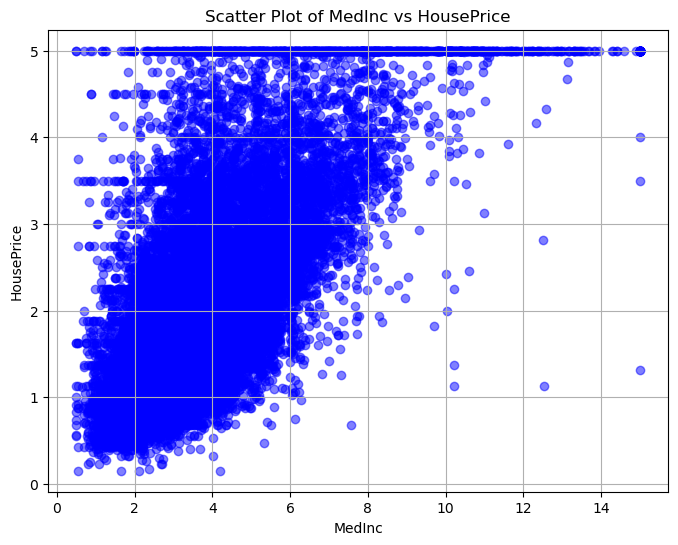

In [34]:
# Scatter plot to display the relationship bt MedInc and HousePrice
medinc = housing_df['MedInc']
houseprice = housing_df['HousePrice']

plt.figure(figsize=(8,6))
plt.scatter(medinc, houseprice, alpha=0.5, color='blue')
plt.title("Scatter Plot of MedInc vs HousePrice")
plt.xlabel("MedInc")
plt.ylabel("HousePrice")
plt.grid(True)
plt.show()

In [35]:
# Calculating the variance inflating factor VIF for each feature in the housing dataset, to identify multicollinearity; the VIF helps determine the
# correlation bt the predictors and drop features with high VIF values
from statsmodels.stats.outliers_influence import variance_inflation_factor

housing_df_vif = housing_df.drop("HousePrice", axis=1)
housing_df_vif = housing_df_vif.apply(pd.to_numeric, errors='coerce')

vif_data = pd.DataFrame()
vif_data["Feature"] = housing_df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(housing_df_vif.values, i) for i in range(len(housing_df_vif.columns))]
print(vif_data)

      Feature         VIF
0      MedInc   11.511140
1    HouseAge    7.195917
2    AveRooms   45.993601
3   AveBedrms   43.590314
4  Population    2.935745
5    AveOccup    1.095243
6    Latitude  559.874071
7   Longitude  633.711654


From the above outout, Lat and Lon have exceptionaly high VIF values indicating severe multicollinearity with other predicting fetaures; addressing this is crucial for improving model stability and interpretability.

In [36]:
# Removing the Lon & Lat Feature from housing_df
housing_df = housing_df.drop(["Latitude", "Longitude"], axis=1)

In [37]:
#Converting selected columns in the housing dataset to numeric
cols_to_convert = [ "MedInc", "HouseAge", "AveRooms", "AveBedrms", "Population", "AveOccup"]
housing_df[cols_to_convert] = housing_df[cols_to_convert].apply(pd.to_numeric, errors="coerce")
housing_df["HousePrice"] = pd.to_numeric(housing_df["HousePrice"], errors="coerce")

# Adding constant to the features
x = sm.add_constant(housing_df.drop("HousePrice", axis=1))
y = housing_df["HousePrice"]

# fit using an OLS Regression models using start model
model = sm.OLS(y,x).fit()

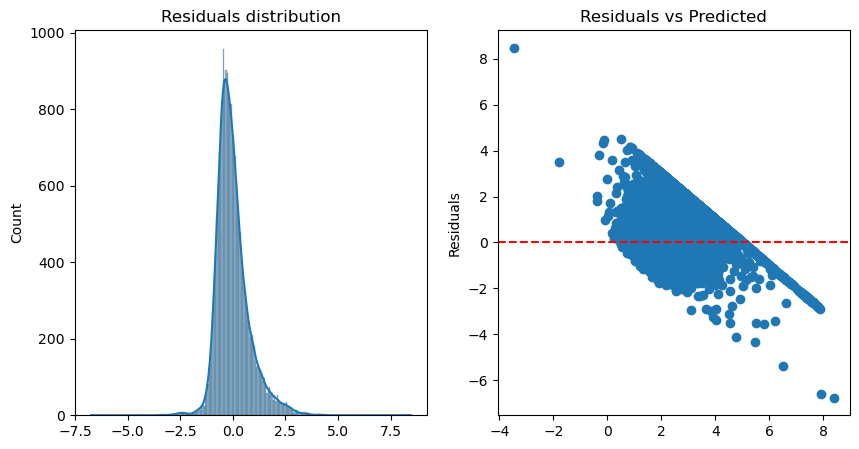

Model coefficients:
 const        -0.439093
MedInc        0.536910
HouseAge      0.016503
AveRooms     -0.211740
AveBedrms     0.993730
Population    0.000022
AveOccup     -0.004877
dtype: float64


In [38]:
# Lets perform residual analysis to validate linear regresion assumptions and 
# visualize the distribution of residuals and their relationship with predicted values
residuals = model.resid

plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title("Residuals distribution")

plt.subplot(1,2,2)
plt.scatter(model.predict(x), residuals)
plt.axhline(y=0, color="red", linestyle='--')
plt.title("Residuals vs Predicted")
plt.ylabel("Residuals")
plt.show()

print("Model coefficients:\n", model.params)

From above diagram, 
- The Histogram displays somewhat normal distribution with normal tail suggesting the presence of outliers and residuals
- The scatter plot shows the residuals against predicted values, Ideally random scatter arround the 0 line is expected but there are some residuals with partivulary large positive or large negative indicating potential outliers affecting the model accuracy
- The model coefficients indicates the impact of each feature against HousPrice; AveBedrms shows the most significant positive influence 

In [39]:
# Compute and interprete the R^2 and MSE Metrics to evaluate the performance of the L.R model on the housing data. 
from sklearn.metrics import mean_squared_error, r2_score

predictions = model.predict(x)

print("R square Score:", r2_score(y, predictions))
print("MSE:", mean_squared_error(y, predictions))

R square Score: 0.5396977345638282
MSE: 0.6129156196698703


So, from the above metrics, the model explains approximately 54% of the variance in the dependent variable with a mean squared error of 0.61 indicating moderate predictive performance.

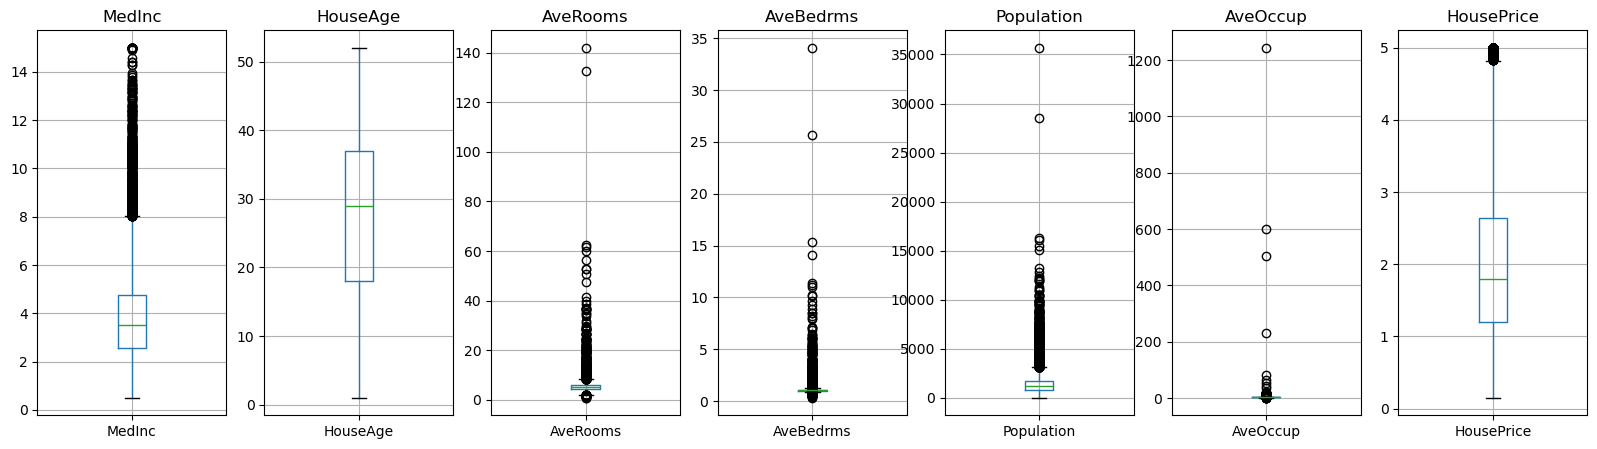

In [40]:
# Let's now visualize the distribution of several predictors and the target variable using boxplots 
# to identify potential outliers that might impact the model evaluation
def plot_boxplots(df):
    fig, axes = plt.subplots(1, len(df.columns), figsize=(20, 5))

    for i, column_name in enumerate(df.columns):
        df.boxplot(column=column_name, ax=axes[i])
        axes[i].set_title(column_name)

    plt.show()

plot_boxplots(housing_df)

From above, you see there's outliers from features like MedInc, HousePrice and Population which adversely affect model performance, it's crucial to address them.

In [47]:
#Funcition to remove outliers
def remove_outliers(df):
    df_no_outliers = df.copy()

    for column_name in df.columns:
        Q1 = df[column_name].quantile(0.25)
        Q3 = df[column_name].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_no_outliers[column_name] = df_no_outliers[column_name].apply(
            lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x
        )
        
        return df_no_outliers

    housing_df_new = remove_outliers(housing_df)

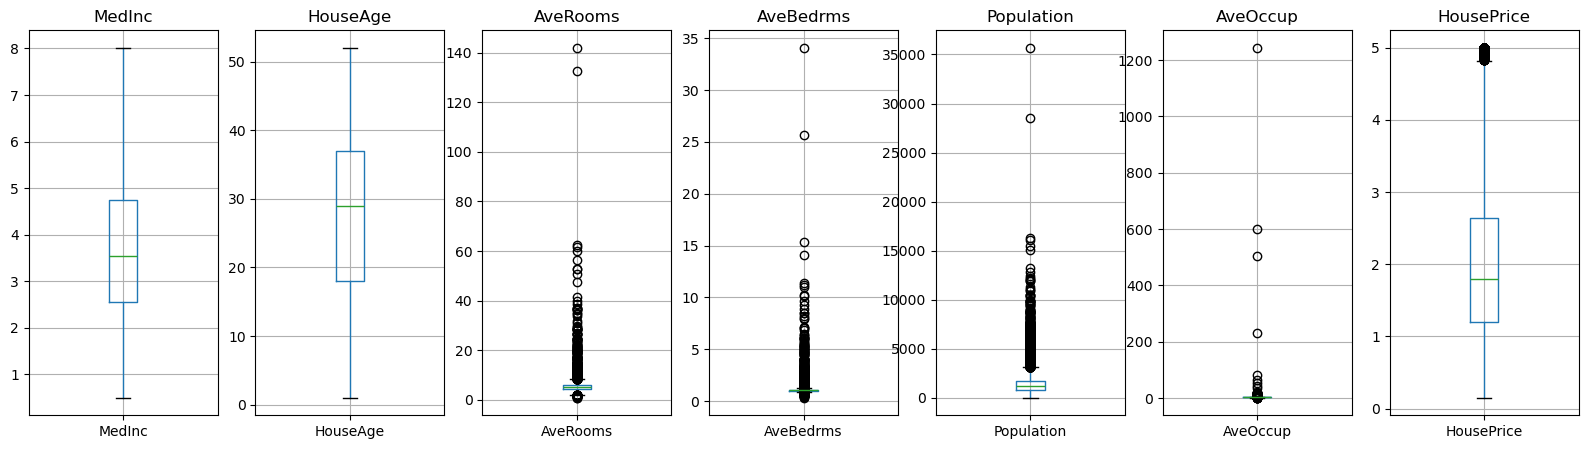

In [48]:
plot_boxplots(housing_df_new)